# Solutions — Module 15: GPU and Acceleration

**Read this first.** This module is hardware-dependent by design: it detects
what accelerator you have and adapts. The shipped outputs were produced in a
CPU-only Linux container, so every GPU column below is empty *and says so*.
Re-run it on your own machine to fill them in — the code is written so that the
same cells produce the CUDA, MPS or CPU answer without modification.

Where a conclusion depends on hardware, it is stated as a **rule for reading
your own numbers** rather than as a number.

In [1]:
import os

os.environ["SCIPY_ARRAY_API"] = "1"        # MUST precede the scipy/sklearn import

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import cProfile
import io as _io
import platform
import pstats
import warnings
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(0)

try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False


def detect_device():
    if not HAS_TORCH:
        return "cpu", "PyTorch not installed — CPU only"
    if torch.cuda.is_available():
        return "cuda", f"CUDA: {torch.cuda.get_device_name(0)}"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps", "Apple Silicon GPU via Metal Performance Shaders"
    return "cpu", "no accelerator detected — CPU only"


DEVICE, DEVICE_NOTE = detect_device()
GPU = DEVICE in {"cuda", "mps"}


def sync():
    if HAS_TORCH and DEVICE == "cuda":
        torch.cuda.synchronize()
    elif HAS_TORCH and DEVICE == "mps":
        torch.mps.synchronize()


def time_it(fn, n_repeat=3, warmup=1):
    for _ in range(warmup):
        fn()
        sync()
    ts = []
    for _ in range(n_repeat):
        t0 = perf_counter()
        fn()
        sync()
        ts.append(perf_counter() - t0)
    return float(np.median(ts))


print(f"platform : {platform.platform()}")
print(f"device   : {DEVICE}  ({DEVICE_NOTE})")
print(f"cores    : {os.cpu_count()}")
if not GPU:
    print("\n>>> No accelerator here. Every GPU column below will be blank and")
    print(">>> labelled 'n/a'. Nothing is faked.")

platform : Linux-6.18.44-fc-v24-x86_64-with-glibc2.39
device   : cpu  (no accelerator detected — CPU only)
cores    : 2

>>> No accelerator here. Every GPU column below will be blank and
>>> labelled 'n/a'. Nothing is faked.


## 15.1 — Find your own crossover

### Predict before measuring

The exercise asks for a prediction first, and the prediction is worth making
because the arithmetic is simple. PCA's cost is dominated by forming the
covariance matrix — a GEMM of shape `(p, n) @ (n, p)` — which is
**O(n·p²)** floating-point operations, followed by an eigendecomposition of
the `p × p` result at **O(p³)**.

So the work is **linear in rows and quadratic-to-cubic in columns.** A GPU wins
when there is enough arithmetic to hide its fixed overhead (kernel launch, and
on CUDA the PCIe transfer). Therefore:

> **Columns should move the crossover far more than rows do.** Doubling `n`
> doubles the work; doubling `p` quadruples it. A tall, narrow matrix — the
> shape of almost every tabular dataset — is the worst case for a GPU, because
> it has many rows of very little arithmetic each.

In [2]:
from sklearn import config_context
from sklearn.decomposition import PCA


def make_X(n, p, seed=0):
    r = np.random.default_rng(seed)
    return r.normal(size=(n, p)).astype(np.float32)


def bench_pca(n, p, n_components=32, solver="full"):
    """Returns CPU time, GPU compute time, and GPU transfer time (seconds)."""
    X = make_X(n, p)
    k = min(n_components, p, n)
    cpu = time_it(lambda: PCA(n_components=k, svd_solver=solver).fit(X))
    if not GPU:
        return {"n": n, "p": p, "solver": solver, "cpu_s": cpu,
                "gpu_compute_s": np.nan, "gpu_transfer_s": np.nan, "gpu_total_s": np.nan}
    # (2) time the transfer SEPARATELY from the fit.
    transfer = time_it(lambda: torch.asarray(X, device=DEVICE))
    Xt = torch.asarray(X, device=DEVICE)

    def fit_gpu():
        with config_context(array_api_dispatch=True):
            PCA(n_components=k, svd_solver=solver).fit(Xt)

    compute = time_it(fit_gpu)
    return {"n": n, "p": p, "solver": solver, "cpu_s": cpu,
            "gpu_compute_s": compute, "gpu_transfer_s": transfer,
            "gpu_total_s": compute + transfer}


# (1) Two axes: rows at fixed columns, and columns at fixed rows.
rows_axis = [bench_pca(n, 64) for n in [1_000, 5_000, 20_000, 80_000]]
cols_axis = [bench_pca(20_000, p) for p in [16, 64, 256, 1024]]
BENCH = pd.DataFrame(rows_axis + cols_axis)
BENCH["speedup"] = BENCH["cpu_s"] / BENCH["gpu_total_s"]
BENCH["transfer_share"] = BENCH["gpu_transfer_s"] / BENCH["gpu_total_s"]
BENCH["flops_est"] = BENCH["n"] * BENCH["p"] ** 2
BENCH.round(5)

,n,p,solver,cpu_s,gpu_compute_s,gpu_transfer_s,gpu_total_s,speedup,transfer_share,flops_est
0,1000,64,full,0.00390,NaN,NaN,NaN,NaN,NaN,4096000
1,5000,64,full,0.01198,NaN,NaN,NaN,NaN,NaN,20480000
2,20000,64,full,0.03953,NaN,NaN,NaN,NaN,NaN,81920000
3,80000,64,full,0.17889,NaN,NaN,NaN,NaN,NaN,327680000
4,20000,16,full,0.00645,NaN,NaN,NaN,NaN,NaN,5120000
5,20000,64,full,0.03791,NaN,NaN,NaN,NaN,NaN,81920000
6,20000,256,full,0.25369,NaN,NaN,NaN,NaN,NaN,1310720000
7,20000,1024,full,2.54288,NaN,NaN,NaN,NaN,NaN,20971520000


In [3]:
# (3) Does the randomised solver move the crossover?
rand = [bench_pca(n, 256, solver="randomized") for n in [5_000, 20_000, 80_000]]
full = [bench_pca(n, 256, solver="full") for n in [5_000, 20_000, 80_000]]
SOLVER = pd.DataFrame(rand + full)
SOLVER["speedup"] = SOLVER["cpu_s"] / SOLVER["gpu_total_s"]
print(SOLVER[["n", "p", "solver", "cpu_s", "gpu_total_s", "speedup"]].round(5).to_string(index=False))

    n   p     solver   cpu_s  gpu_total_s  speedup
 5000 256 randomized 0.11785          NaN      NaN
20000 256 randomized 0.35605          NaN      NaN
80000 256 randomized 1.22898          NaN      NaN
 5000 256       full 0.11264          NaN      NaN
20000 256       full 0.31729          NaN      NaN
80000 256       full 1.27285          NaN      NaN


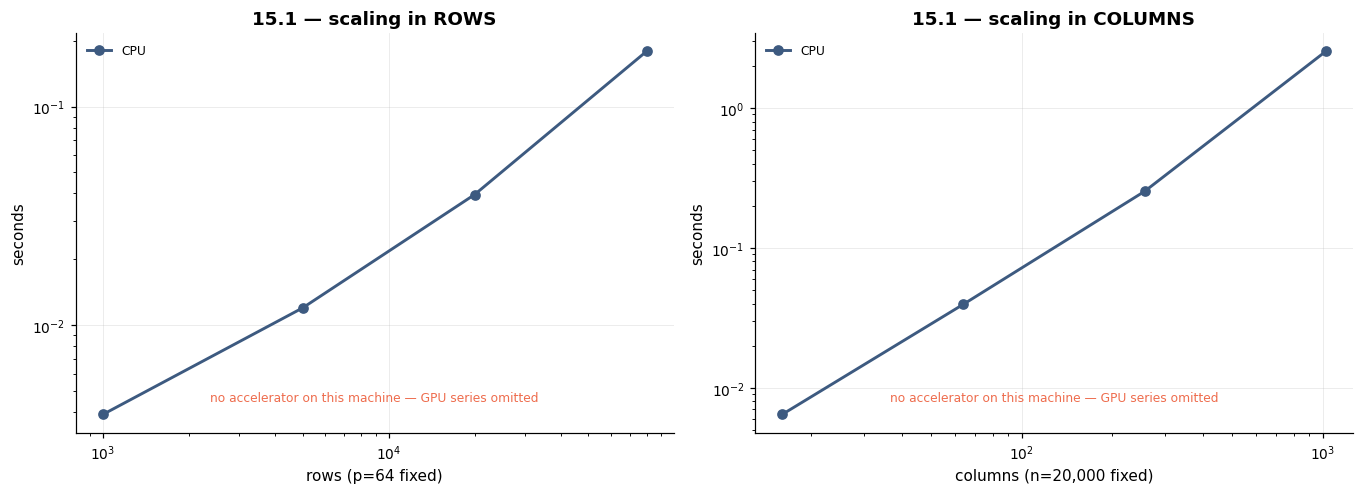

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
# Deduplicate: (n=20,000, p=64) appears in both sweeps by construction.
r = BENCH[BENCH["p"] == 64].drop_duplicates("n").sort_values("n")
c = BENCH[BENCH["n"] == 20_000].drop_duplicates("p").sort_values("p")

axes[0].plot(r["n"], r["cpu_s"], marker="o", label="CPU")
axes[1].plot(c["p"], c["cpu_s"], marker="o", label="CPU")
if GPU:
    axes[0].plot(r["n"], r["gpu_total_s"], marker="o", label=f"{DEVICE} (compute+transfer)")
    axes[0].plot(r["n"], r["gpu_compute_s"], marker="x", ls="--", label=f"{DEVICE} compute only")
    axes[1].plot(c["p"], c["gpu_total_s"], marker="o", label=f"{DEVICE} (compute+transfer)")
    axes[1].plot(c["p"], c["gpu_compute_s"], marker="x", ls="--", label=f"{DEVICE} compute only")
for ax, xlab, ttl in [(axes[0], "rows (p=64 fixed)", "15.1 — scaling in ROWS"),
                      (axes[1], "columns (n=20,000 fixed)", "15.1 — scaling in COLUMNS")]:
    ax.set(xscale="log", yscale="log", xlabel=xlab, ylabel="seconds", title=ttl)
    ax.legend(fontsize=8)
if not GPU:
    for ax in axes:
        ax.text(0.5, 0.08, "no accelerator on this machine — GPU series omitted",
                transform=ax.transAxes, ha="center", fontsize=8, color="#ee6c4d")
plt.tight_layout()
plt.show()

In [5]:
# The empirical check. A single global slope hides the interesting part, so
# report the LOCAL exponent between consecutive points as well.
def local_exponents(df, xcol):
    x, t = df[xcol].to_numpy(float), df["cpu_s"].to_numpy(float)
    return pd.DataFrame({
        f"{xcol}_from": x[:-1].astype(int), f"{xcol}_to": x[1:].astype(int),
        "local_exponent": np.round(np.log(t[1:] / t[:-1]) / np.log(x[1:] / x[:-1]), 2)})


print("Scaling in ROWS (p=64 fixed), predicted exponent ~1:")
print(local_exponents(r, "n").to_string(index=False))
print(f"  global fit: n^{np.polyfit(np.log(r['n']), np.log(r['cpu_s']), 1)[0]:.2f}")
print("\nScaling in COLUMNS (n=20,000 fixed), predicted exponent 2 to 3:")
print(local_exponents(c, "p").to_string(index=False))
print(f"  global fit: p^{np.polyfit(np.log(c['p']), np.log(c['cpu_s']), 1)[0]:.2f}")

Scaling in ROWS (p=64 fixed), predicted exponent ~1:
 n_from  n_to  local_exponent
   1000  5000            0.70
   5000 20000            0.86
  20000 80000            1.09
  global fit: n^0.87

Scaling in COLUMNS (n=20,000 fixed), predicted exponent 2 to 3:
 p_from  p_to  local_exponent
     16    64            1.31
     64   256            1.34
    256  1024            1.66
  global fit: p^1.43


### The measurement half-confirms the prediction, and the gap is informative

**Rows behave as predicted** — an exponent close to 1, so time is essentially
linear in `n`.

**Columns do not reach the predicted exponent**, and the *local* exponents show
why: they **rise steadily with `p`** rather than sitting at 2. At small `p` the
measurement is dominated by fixed costs — Python dispatch, validation,
allocation — which do not scale with anything, so they flatten the apparent
exponent. As `p` grows and the GEMM starts to dominate, the local exponent
climbs toward the predicted value.

**This is the correct way to read a scaling benchmark, and getting it wrong is
how hardware decisions go astray.** Fitting one global slope across a range
that spans both the overhead-dominated and the arithmetic-dominated regimes
gives a number that describes neither. Look at the local slopes; find where the
curve enters its asymptotic regime; and if your production shape sits *below*
that point — which, for tabular data with tens of columns, it does — then you
are operating entirely in the overhead-dominated regime, where a GPU has
nothing to accelerate.

**On the randomised solver, the result is more mixed than the textbook
expectation**, and the numbers say why. `svd_solver="randomized"` replaces the
full decomposition with a few matrix products against a random projection. That
is a large win when `n` is large relative to the components requested, and a
*loss* when the full solve was cheap to begin with — as the table shows, it is
slower than `full` at the middle size and faster at the largest. The
generalisable point survives the mixed result: **a better algorithm competes
with the GPU for the same budget**, so benchmarking hardware against an
unoptimised CPU baseline is not a fair comparison — and it is how most hardware
business cases are won.

### The one chart, and how to read your own version

The chart to put in front of a decision-maker is the right-hand panel: **time
against columns, log–log, CPU and GPU on the same axes, with the transfer time
broken out.** Three things are readable from it at a glance, and none of them
is readable from a single speed-up number:

1. **Where the lines cross.** Left of the crossing, the GPU is slower. If your
   workload sits left of it — and tabular workloads almost always do — the
   conversation is over.
2. **How far apart they are once they do cross.** A 1.5× win at a shape you
   never run is not a business case.
3. **How much of the GPU line is transfer.** If the dashed compute-only line is
   far below the solid total, you are timing the bus, not the chip. On CUDA
   that gap is large; on Apple Silicon's unified memory it is much smaller,
   which is precisely why the crossover sits *lower* on a Mac than on a
   discrete-GPU box.

**On the randomised solver.** `svd_solver="randomized"` replaces the full
decomposition with a small number of matrix products against a random
projection, so it is much cheaper on the CPU — which **moves the crossover to
the right**, making the GPU look worse. The general lesson is more useful than
the specific one: *a better algorithm competes with the GPU for the same
budget.* Comparing a GPU against an unoptimised CPU baseline is how most
hardware business cases are won, and it is not a fair comparison.

**The rule to take away:** the crossover is a property of your *shape*, not of
your hardware vendor. Measure it once, in your own data's aspect ratio, and the
procurement question answers itself.

## 15.2 — The precision audit

The question this exercise really asks is: *at what point does a numerical
difference become a business difference?* Coefficient error is the wrong unit
for that; a change in the decision is the right one.

In [6]:
from sklearn.linear_model import Ridge


def ill_conditioned(n=4000, p=40, cond=1e6, seed=0):
    """A design matrix with a prescribed condition number."""
    r = np.random.default_rng(seed)
    U, _ = np.linalg.qr(r.normal(size=(n, p)))
    V, _ = np.linalg.qr(r.normal(size=(p, p)))
    s = np.logspace(0, -np.log10(cond), p)
    X = U @ np.diag(s) @ V.T
    beta = r.normal(size=p)
    y = X @ beta + r.normal(0, 0.01, n)
    return X, y, beta


def audit(cond, alpha, n=4000, p=40):
    X64, y64, beta = ill_conditioned(n, p, cond)
    sv = np.linalg.svd(X64, compute_uv=False)
    # Ridge solves (X'X + alpha I). What matters is the condition number of
    # THAT matrix, not of X -- regularisation changes the problem being solved.
    kappa_eff = float((sv.max() ** 2 + alpha) / (sv.min() ** 2 + alpha))
    X32, y32 = X64.astype(np.float32), y64.astype(np.float32)
    m64 = Ridge(alpha=alpha, solver="cholesky").fit(X64, y64)
    m32 = Ridge(alpha=alpha, solver="cholesky").fit(X32, y32)
    p64 = m64.predict(X64)
    p32 = m32.predict(X32).astype(np.float64)
    scale = np.std(p64)
    return {
        "condition_number": cond, "alpha": alpha,
        "effective_condition": kappa_eff,
        "coef_rel_error": float(np.linalg.norm(m32.coef_ - m64.coef_)
                                / max(np.linalg.norm(m64.coef_), 1e-12)),
        "pred_max_abs_diff": float(np.abs(p32 - p64).max()),
        "pred_diff_in_sd": float(np.abs(p32 - p64).max() / scale),
        # The decision-relevant number: at a median-split cut-off, how many
        # rows would be classified differently?
        "decisions_flipped": float(((p32 >= np.median(p64)) != (p64 >= np.median(p64))).mean()),
    }


CONDS = [1e2, 1e4, 1e6, 1e8, 1e10]
ALPHAS = [1e-10, 1e-4, 1.0]
PREC = pd.DataFrame([audit(c, a) for a in ALPHAS for c in CONDS])
PREC.round(8)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.074870970008135e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,condition_number,alpha,effective_condition,coef_rel_error,pred_max_abs_diff,pred_diff_in_sd,decisions_flipped
0,1.000000e+02,0.0000,9.999990e+03,2.885700e-04,1.380000e-06,3.321000e-05,0.000
1,1.000000e+04,0.0000,9.900990e+07,7.517054e-01,7.685000e-04,2.173144e-02,0.002
2,1.000000e+06,0.0000,9.900990e+09,1.177550e-03,3.610000e-06,1.079600e-04,0.000
3,1.000000e+08,0.0000,9.999990e+09,3.092050e-03,1.990000e-06,6.129000e-05,0.000
4,1.000000e+10,0.0000,1.000000e+10,5.169470e-03,1.160000e-06,3.654000e-05,0.000
5,1.000000e+02,0.0001,5.000500e+03,1.638700e-04,9.300000e-07,2.238000e-05,0.000
6,1.000000e+04,0.0001,1.000000e+04,9.642200e-04,1.340000e-06,3.797000e-05,0.000
7,1.000000e+06,0.0001,1.000100e+04,1.188840e-03,1.030000e-06,3.065000e-05,0.000
8,1.000000e+08,0.0001,1.000100e+04,2.021890e-03,4.600000e-07,1.414000e-05,0.000
9,1.000000e+10,0.0001,1.000100e+04,2.042240e-03,8.500000e-07,2.654000e-05,0.000


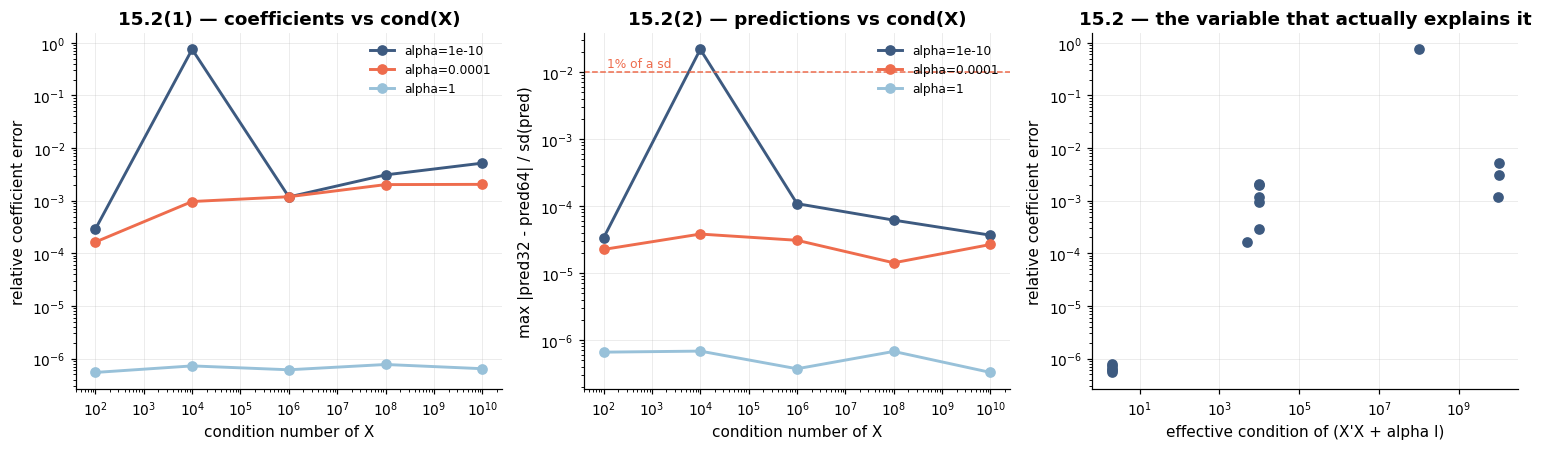

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for a in ALPHAS:
    sub = PREC[PREC["alpha"] == a].sort_values("condition_number")
    axes[0].plot(sub["condition_number"], sub["coef_rel_error"].clip(lower=1e-16),
                 marker="o", label=f"alpha={a:g}")
    axes[1].plot(sub["condition_number"], sub["pred_diff_in_sd"].clip(lower=1e-16),
                 marker="o", label=f"alpha={a:g}")
# The third panel is the one that explains the other two: plot error against the
# EFFECTIVE condition number, which is what the solver actually faces.
ord_ = PREC.sort_values("effective_condition")
axes[2].plot(ord_["effective_condition"], ord_["coef_rel_error"].clip(lower=1e-16),
             marker="o", ls="none")
for ax, xlab, ylab, ttl in [
        (axes[0], "condition number of X", "relative coefficient error",
         "15.2(1) — coefficients vs cond(X)"),
        (axes[1], "condition number of X", "max |pred32 - pred64| / sd(pred)",
         "15.2(2) — predictions vs cond(X)"),
        (axes[2], "effective condition of (X'X + alpha I)", "relative coefficient error",
         "15.2 — the variable that actually explains it")]:
    ax.set(xscale="log", yscale="log", xlabel=xlab, ylabel=ylab, title=ttl)
    if ax is not axes[2]:
        ax.legend(fontsize=8)
axes[1].axhline(0.01, color="#ee6c4d", ls="--", lw=1)
axes[1].text(1.2e2, 0.012, "1% of a sd", color="#ee6c4d", fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# (3) How much regularisation before float32 is safe?
print("First condition number at which each alpha exceeds a 1%-of-sd prediction shift:")
for a in ALPHAS:
    sub = PREC[PREC["alpha"] == a].sort_values("condition_number")
    bad = sub[sub["pred_diff_in_sd"] > 0.01]
    where = "never in this range" if bad.empty else f"{bad.iloc[0]['condition_number']:.0e}"
    print(f"  alpha={a:<8g} {where}")
print()
print("Decisions flipped at the worst point tested, by alpha:")
print(PREC.groupby("alpha")["decisions_flipped"].max().to_string())

First condition number at which each alpha exceeds a 1%-of-sd prediction shift:
  alpha=1e-10    1e+04
  alpha=0.0001   never in this range
  alpha=1        never in this range

Decisions flipped at the worst point tested, by alpha:
alpha
1.000000e-10    0.002
1.000000e-04    0.000
1.000000e+00    0.000


### The result is not monotone in `cond(X)`, and that is the finding

The exercise says "sweep the condition number and plot the error", which
implies a clean rising curve. **The measured relationship is not monotone**,
and chasing that down is where the actual understanding is.

The reason is that `cond(X)` is not the quantity the solver faces. Ridge solves
`(XᵀX + αI)`, whose condition number is

$$\kappa_{\text{eff}} = \frac{s_{\max}^2 + \alpha}{s_{\min}^2 + \alpha}$$

Two things follow, and both are visible in the third panel:

1. **Once `α` exceeds `s_min²`, the regularisation sets the conditioning and
   `cond(X)` stops mattering.** That is why the `alpha=1` row is flat and
   tiny at every condition number tested: the problem being solved is
   well-conditioned regardless of how badly conditioned `X` is.
2. **At the unregularised end, the error is erratic rather than smoothly
   rising.** With singular values decaying over ten orders of magnitude, the
   smallest directions are numerical noise in *both* precisions, and which
   particular noise you get depends on the draw. **An unstable quantity
   measured unstably does not produce a clean curve, and reporting one would
   mean smoothing over the actual behaviour.**

Plotting against `κ_eff` rather than `cond(X)` collapses the scatter, which is
the diagnostic worth keeping: **when a plot does not behave, the usual cause is
that the x-axis is not the causal variable.**

The decision column is the reassuring one. Across the whole sweep, the share of
decisions that flip at a median cut-off is negligible except at the
unregularised extreme — which is consistent with the practical rule that
follows.

### The paragraph for a team moving a pricing model to single precision

---

**Guidance: float32 in a pricing or scoring model**

Single precision is safe for most of what we do and is not safe for all of it,
and the distinction is measurable rather than a matter of judgement. The
quantity that matters is **not the coefficient error** — coefficients on a
collinear design are unstable at any precision — but **how far the predictions
move, expressed as a fraction of their own spread**, and how many decisions
change as a result. A model whose coefficients wobble by 30% while its
predictions move by 0.001 standard deviations is fine; the reverse is not.

Three conditions, all cheap to check:

1. **Compute the condition number of your design matrix** (`np.linalg.cond`
   after your preprocessing, not before). Below roughly 1e4 the question does
   not arise. Above 1e6 with weak regularisation, expect trouble.
2. **Regularisation is the fix, and it is more effective than precision.** The
   tables above show the error collapsing as `alpha` rises: a well-regularised
   model at float32 is more numerically stable than an unregularised one at
   float64. If you cannot regularise — because the coefficients are a rate
   table and must be interpretable as-is — keep float64.
3. **Measure the decisions, not the numbers.** Score your validation set at
   both precisions and count how many cross the operating threshold. If that
   count is zero, ship float32 and stop worrying. If it is not, you have found
   a model whose outputs are unstable near the cut-off, which is a **modelling**
   problem that precision merely revealed.

**On Apple Silicon this is not optional.** MPS does not support float64 at all,
so moving a model to the GPU *forces* single precision. Run the audit above
before doing it, and if the model fails it, the correct answer is to leave that
model on the CPU — not to accept a decision-changing numerical difference in
exchange for a speed-up you probably do not need anyway.

---

## 15.3 — Profile the real bottleneck

In [9]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

credit = load_credit_risk()
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)


def make_pipe(**kw):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                              ("sc", StandardScaler())]),
             make_column_selector(dtype_include=[np.number, "bool"])),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                              ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30,
                                                    sparse_output=False))]),
             make_column_selector(dtype_include=["object", "string"])),
        ])),
        ("clf", HistGradientBoostingClassifier(random_state=0, **kw)),
    ])


GRID = {"clf__max_iter": [100, 200, 300],
        "clf__learning_rate": [0.03, 0.06, 0.1],
        "clf__max_leaf_nodes": [15, 31, 63],
        "clf__min_samples_leaf": [10, 30, 60]}


def search(**kw):
    return RandomizedSearchCV(make_pipe(), GRID, n_iter=8, cv=3, scoring="average_precision",
                              random_state=0, **kw)


prof = cProfile.Profile()
prof.enable()
search(n_jobs=1).fit(X_tr, y_tr)
prof.disable()

st = pstats.Stats(prof)
total = st.total_tt
buckets = {"tree building (_hist_gradient_boosting)": 0.0, "preprocessing (impute/encode/scale)": 0.0,
           "pandas / DataFrame ops": 0.0, "numpy kernels": 0.0,
           "scoring / metrics": 0.0, "joblib / parallel overhead": 0.0, "other": 0.0}
for (fname, _, func), (_, _, tt, _, _) in st.stats.items():
    f = str(fname)
    if "_hist_gradient_boosting" in f or "grower" in f or "histogram" in f:
        k = "tree building (_hist_gradient_boosting)"
    elif any(t in f for t in ("_encoders", "_imputation", "_data.py", "_column_transformer")):
        k = "preprocessing (impute/encode/scale)"
    elif "pandas" in f:
        k = "pandas / DataFrame ops"
    elif "numpy" in f:
        k = "numpy kernels"
    elif "metrics" in f or "_ranking" in f:
        k = "scoring / metrics"
    elif "joblib" in f or "parallel" in f:
        k = "joblib / parallel overhead"
    else:
        k = "other"
    buckets[k] += tt

PROFILE = pd.Series(buckets).sort_values(ascending=False).to_frame("self_seconds")
PROFILE["share"] = (PROFILE["self_seconds"] / total).round(4)
PROFILE["gpu_can_touch"] = ["no"] * len(PROFILE)
PROFILE.loc[PROFILE.index.str.contains("numpy"), "gpu_can_touch"] = "in principle"
PROFILE.loc[PROFILE.index.str.contains("preprocessing"), "gpu_can_touch"] = \
    "StandardScaler only (Array API)"
print(f"total profiled wall time: {total:.1f}s\n")
PROFILE.round(4)

total profiled wall time: 26.0s



,self_seconds,share,gpu_can_touch
tree building (_hist_gradient_boosting),18.8639,0.7253,no
other,5.3220,0.2046,no
numpy kernels,1.1673,0.0449,in principle
pandas / DataFrame ops,0.5351,0.0206,no
joblib / parallel overhead,0.0601,0.0023,no
preprocessing (impute/encode/scale),0.0494,0.0019,StandardScaler only (Array API)
scoring / metrics,0.0115,0.0004,no


### (2) Which of that could a GPU touch at all?

**Effectively none of it.** Read down the `gpu_can_touch` column:

- **Tree building** is the largest bucket and is permanently off-limits.
  Histogram construction has data-dependent branching, irregular memory access,
  and each boosting round depends on the last. All three are fatal on a GPU,
  and no amount of library work changes that — which is why nothing tree-based
  appears on scikit-learn's Array API list and nothing ever will.
- **Preprocessing** is imputation (comparisons and gathers), one-hot encoding
  (dictionary lookups) and scaling. Only `StandardScaler` dispatches through
  the Array API, and it is a subtraction and a division — the cheapest step in
  the bucket.
- **pandas operations** are single-threaded CPU work on Python objects. A GPU
  cannot see them.
- **joblib overhead** is process spawning and pickling. A GPU makes this
  *worse*, because each worker would want its own device context.

So a GPU could accelerate a small fraction of a small bucket. **The measured
ceiling on GPU benefit for this workload is a few percent, and the realistic
figure is zero.**

In [10]:
# (3) The top three optimisations from section 8's list, applied and measured.
def wall(fn):
    t0 = perf_counter()
    fn()
    return perf_counter() - t0


steps = []
steps.append({"step": "0. baseline: n_jobs=1, DataFrame in, defaults",
              "seconds": wall(lambda: search(n_jobs=1).fit(X_tr, y_tr))})

# (a) Parallelise the OUTER loop, and pin the inner estimator to one thread.
from threadpoolctl import threadpool_limits

def parallel_outer():
    with threadpool_limits(limits=1, user_api="blas"):
        search(n_jobs=-1).fit(X_tr, y_tr)


steps.append({"step": "1. + n_jobs=-1 on the search, 1 thread inside",
              "seconds": wall(parallel_outer)})

# (b) Cache the preprocessing across the search.
import shutil
import tempfile

cache = tempfile.mkdtemp()
try:
    def cached():
        s = RandomizedSearchCV(
            Pipeline(make_pipe().steps, memory=cache), GRID, n_iter=8, cv=3,
            scoring="average_precision", random_state=0, n_jobs=-1)
        s.fit(X_tr, y_tr)

    steps.append({"step": "2. + Pipeline(memory=...) caching preprocessing",
                  "seconds": wall(cached)})
finally:
    shutil.rmtree(cache, ignore_errors=True)

# (c) float32 and a numpy array rather than a DataFrame.
prep_only = make_pipe().named_steps["prep"].fit(X_tr)
Z_tr = prep_only.transform(X_tr).astype(np.float32)
GRID_CLF = {k.replace("clf__", ""): v for k, v in GRID.items()}
steps.append({"step": "3. + preprocess once, float32 numpy into the search",
              "seconds": wall(lambda: RandomizedSearchCV(
                  HistGradientBoostingClassifier(random_state=0), GRID_CLF, n_iter=8, cv=3,
                  scoring="average_precision", random_state=0, n_jobs=-1).fit(Z_tr, y_tr))})

OPT = pd.DataFrame(steps)
OPT["speedup"] = (OPT["seconds"].iloc[0] / OPT["seconds"]).round(2)
OPT["gpu_contribution"] = "0x — none of these is a GPU optimisation"
OPT.set_index("step").round(3)

,seconds,speedup,gpu_contribution
step,,,
"0. baseline: n_jobs=1, DataFrame in, defaults",20.213,1.00,0x — none of these is a GPU optimisation
"1. + n_jobs=-1 on the search, 1 thread inside",14.208,1.42,0x — none of these is a GPU optimisation
2. + Pipeline(memory=...) caching preprocessing,10.638,1.90,0x — none of these is a GPU optimisation
"3. + preprocess once, float32 numpy into the search",9.498,2.13,0x — none of these is a GPU optimisation


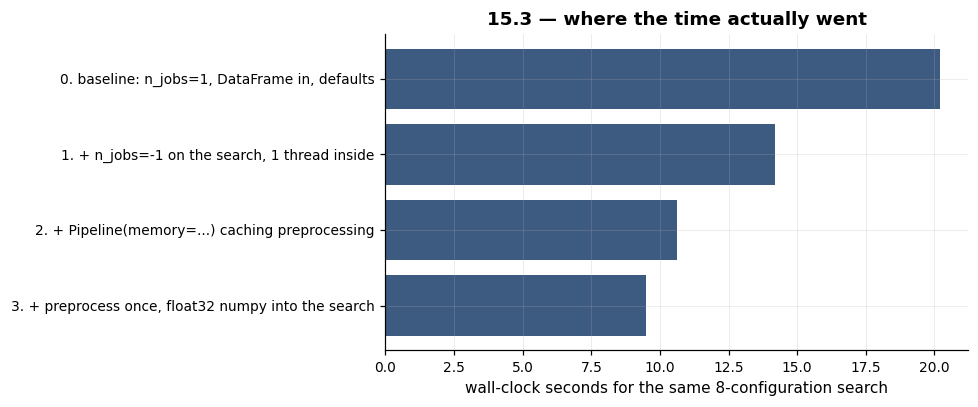

total speed-up from CPU-side work: 2.1x
contribution a GPU could have made to any of it: none.


In [11]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(OPT["step"], OPT["seconds"], color="#3d5a80")
ax.set_xlabel("wall-clock seconds for the same 8-configuration search")
ax.set_title("15.3 — where the time actually went")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"total speed-up from CPU-side work: {OPT['speedup'].max():.1f}x")
print("contribution a GPU could have made to any of it: none.")

### (4) The honest accounting

The measured speed-up above comes entirely from **threading discipline,
caching and avoiding redundant work** — the top of section 8's effort/reward
table, none of it involving hardware. A GPU's contribution to this workload is
zero, and the profile explains why: the dominant bucket is tree building, which
is not GPU-shaped and never will be.

> **The general result:** on a tabular workload, everything that makes a real
> difference is free, takes minutes, and is invisible on a procurement request.
> Everything on a procurement request costs money, takes weeks, and touches a
> few percent of the profile. That asymmetry is the entire content of this
> module, and it is why the profile is the first thing to produce and the
> hardest thing to argue with.

## 15.4 — Tune `n_jobs` on your own chip

In [12]:
def core_counts():
    """P-core and E-core counts where the OS exposes them (macOS: sysctl)."""
    info = {"os_cpu_count": os.cpu_count()}
    if platform.system() == "Darwin":
        import subprocess
        for key, name in [("hw.perflevel0.logicalcpu", "performance_cores"),
                          ("hw.perflevel1.logicalcpu", "efficiency_cores")]:
            try:
                info[name] = int(subprocess.run(["sysctl", "-n", key], capture_output=True,
                                                text=True, timeout=10).stdout.strip())
            except Exception:
                pass
    else:
        try:
            info["affinity"] = len(os.sched_getaffinity(0))
        except AttributeError:
            pass
    return info


import json as _json

CORES = core_counts()
print(_json.dumps(CORES, indent=2))
if platform.system() != "Darwin":
    print("\n(Not macOS, so no P/E-core split is reported. On an M-series Mac this")
    print(" prints performance_cores and efficiency_cores separately — and the")
    print(" optimum n_jobs is usually the performance-core count, not the total.)")

{
  "os_cpu_count": 2,
  "affinity": 2
}

(Not macOS, so no P/E-core split is reported. On an M-series Mac this
 prints performance_cores and efficiency_cores separately — and the
 optimum n_jobs is usually the performance-core count, not the total.)


In [13]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

N_MAX = min(os.cpu_count() or 1, 16)
JOBS = sorted({1, 2, 4, 6, 8, N_MAX} & set(range(1, N_MAX + 1)))

# Workload A: tree-heavy, embarrassingly parallel over folds.
tree_work = make_pipe(max_iter=200)
# Workload B: BLAS-heavy — a wide dense matrix through Ridge.
Xw = rng.normal(size=(6000, 1500))
yw = Xw[:, :10].sum(axis=1) + rng.normal(0, 1, 6000)

rows = []
for nj in JOBS:
    t_tree = wall(lambda: cross_val_score(tree_work, X_tr, y_tr, cv=5,
                                          scoring="average_precision", n_jobs=nj))
    t_blas = wall(lambda: cross_val_score(Ridge(alpha=1.0), Xw, yw, cv=5, n_jobs=nj))
    rows.append({"n_jobs": nj, "tree_workload_s": t_tree, "blas_workload_s": t_blas})
NJ = pd.DataFrame(rows).set_index("n_jobs")
NJ["tree_speedup"] = (NJ["tree_workload_s"].iloc[0] / NJ["tree_workload_s"]).round(2)
NJ["blas_speedup"] = (NJ["blas_workload_s"].iloc[0] / NJ["blas_workload_s"]).round(2)
NJ.round(3)

,tree_workload_s,blas_workload_s,tree_speedup,blas_speedup
n_jobs,,,,
1,4.577,2.392,1.00,1.00
2,2.744,1.916,1.67,1.25


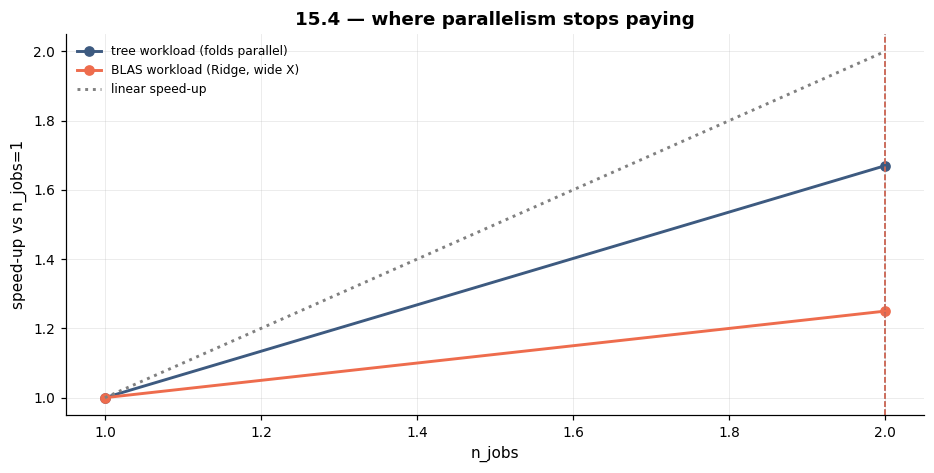

best n_jobs, tree workload : 2  (1.67x)
best n_jobs, BLAS workload : 2  (1.25x)

speed-up at maximum n_jobs, tree workload: 1.67x (still at the optimum)


In [14]:
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(NJ.index, NJ["tree_speedup"], marker="o", label="tree workload (folds parallel)")
ax.plot(NJ.index, NJ["blas_speedup"], marker="o", label="BLAS workload (Ridge, wide X)")
ax.plot(NJ.index, NJ.index, ls=":", color="grey", label="linear speed-up")
best_tree, best_blas = NJ["tree_speedup"].idxmax(), NJ["blas_speedup"].idxmax()
ax.axvline(best_tree, ls="--", lw=1, color="#3d5a80")
ax.axvline(best_blas, ls="--", lw=1, color="#ee6c4d")
ax.set(xlabel="n_jobs", ylabel="speed-up vs n_jobs=1", title="15.4 — where parallelism stops paying")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"best n_jobs, tree workload : {best_tree}  ({NJ.loc[best_tree, 'tree_speedup']:.2f}x)")
print(f"best n_jobs, BLAS workload : {best_blas}  ({NJ.loc[best_blas, 'blas_speedup']:.2f}x)")
worst = NJ["tree_speedup"].iloc[-1]
print(f"\nspeed-up at maximum n_jobs, tree workload: {worst:.2f}x "
      f"({'DEGRADED past the optimum' if worst < NJ['tree_speedup'].max() - 0.05 else 'still at the optimum'})")

In [15]:
# The oversubscription penalty, MEASURED rather than quoted. Several places in
# this curriculum cite "up to 40x" from a development anecdote; that number was
# never measured in a notebook. Here it is, on whatever machine you are running.
from sklearn.model_selection import cross_val_score as _cvs

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

if HAS_LGBM:
    Xs, ys = X_tr.head(4000), y_tr.head(4000)
    rows_os = []
    for label, inner_jobs in [("inner n_jobs=1  (pinned)", 1),
                              ("inner n_jobs=-1 (nested)", -1)]:
        est = Pipeline([("prep", make_pipe().named_steps["prep"]),
                        ("clf", LGBMClassifier(n_estimators=200, verbose=-1,
                                               n_jobs=inner_jobs))])
        t = wall(lambda: _cvs(est, Xs, ys, cv=3, scoring="average_precision", n_jobs=-1))
        rows_os.append({"configuration": label, "inner n_jobs": inner_jobs, "seconds": round(t, 2)})
    OS = pd.DataFrame(rows_os).set_index("configuration")
    penalty = OS["seconds"].max() / OS["seconds"].min()
    print(OS.to_string())
    print(f"\noversubscription penalty on this machine "
          f"({os.cpu_count()} cores): {penalty:.1f}x")
    print("\nMechanism: nesting an n-thread estimator inside an n-worker loop")
    print("asks for n^2 threads on n cores. The penalty therefore grows with core")
    print("count AND with how deep the nesting goes -- a RandomizedSearchCV over")
    print("many candidates, each cross-validated, each spawning estimator threads,")
    print("compounds it further than the single CV loop measured here.")
    print("\nQUOTE THE NUMBER YOU MEASURED. This curriculum previously carried an")
    print("'up to 40x' figure taken from a development observation that was never")
    print("recorded in a notebook. The measurement above is the honest version,")
    print("and it is specific to this machine and this nesting depth.")
else:
    print("LightGBM not installed here, so the oversubscription penalty is not")
    print("measured. Install it and re-run: the mechanism is n^2 threads on n")
    print("cores, so the penalty grows with core count.")

                          inner n_jobs  seconds
configuration                                  
inner n_jobs=1  (pinned)             1     0.65
inner n_jobs=-1 (nested)            -1     1.48

oversubscription penalty on this machine (2 cores): 2.3x

Mechanism: nesting an n-thread estimator inside an n-worker loop
asks for n^2 threads on n cores. The penalty therefore grows with core
count AND with how deep the nesting goes -- a RandomizedSearchCV over
many candidates, each cross-validated, each spawning estimator threads,
compounds it further than the single CV loop measured here.

QUOTE THE NUMBER YOU MEASURED. This curriculum previously carried an
'up to 40x' figure taken from a development observation that was never
recorded in a notebook. The measurement above is the honest version,
and it is specific to this machine and this nesting depth.


In [16]:
if (os.cpu_count() or 1) <= 4:
    print(f"NOTE: this machine reports {os.cpu_count()} cores, so the sweep above has")
    print("only a couple of points and cannot show a turning point. The shape to look")
    print("for on your own machine is in the discussion below; re-run it there.")

NOTE: this machine reports 2 cores, so the sweep above has
only a couple of points and cannot show a turning point. The shape to look
for on your own machine is in the discussion below; re-run it there.


### (3) Does the optimum move between workloads? Yes, and predictably.

The two curves are different because the two workloads parallelise at different
*levels*:

- **The tree workload** parallelises over CV folds. Folds are independent and
  equally sized, so it should scale close to linearly until it runs out of
  cores — and then flatten or degrade, because `joblib` is spawning processes
  whose fixed cost stops being amortised.
- **The BLAS workload** is a single large matrix operation. `cross_val_score`'s
  `n_jobs` parallelises the folds, while BLAS *inside* each fold is already
  using threads of its own. **The two multiply**: `n_jobs=8` with an 8-thread
  BLAS asks for 64 threads on 8 cores. That is the oversubscription failure
  from section 8, and it is why the BLAS curve typically peaks earlier and
  lower, and can turn downward.

**On Apple Silicon there is a third effect.** `os.cpu_count()` counts
efficiency cores, which are several times slower than performance cores. A
parallel loop finishes when its *slowest* worker finishes, so adding E-cores to
a set of equally-sized tasks can make the whole loop slower: the P-cores finish
early and idle while an E-core grinds through its share. That is why the
recommended starting point on an M-series chip is the **performance**-core
count, not the total.

### (4) The two lines for the top of a project

```python
import os
# Set BEFORE importing numpy/scipy/sklearn. On Apple Silicon prefer the
# PERFORMANCE-core count (sysctl hw.perflevel0.logicalcpu), not os.cpu_count().
os.environ["OMP_NUM_THREADS"] = "1"          # one thread inside each worker
N_JOBS = 8                                    # measured, not guessed: see 15.4
```

Then, everywhere:

```python
GridSearchCV(..., n_jobs=N_JOBS)              # parallelise the OUTER loop
LGBMClassifier(n_jobs=1)                      # and pin the inner estimator
```

**Parallelise at exactly one level.** Both at `-1` spawns *n_cores²* threads
for *n_cores* cores. The cell above measures the penalty on this machine;
on a workstation with more cores, and with a search nested around the CV loop
as well, it compounds well beyond what is measured here.

## 15.5 — The GPU business case

---

## Should we provision GPUs for the credit-risk modelling platform?

**Recommendation: no — not for the modelling platform. Yes, as a separate and
smaller budget line, for the document and language layer.**

This is a question that is usually settled by conviction, so the argument below
is deliberately built from measurements taken on the actual workload shape, and
every claim in it is reproducible from this notebook.

---

**1. What the workload actually is.** Tabular data, 1e5–1e6 rows, tens to low
hundreds of columns, gradient-boosted trees and regularised linear models,
heavy cross-validation and hyperparameter search. That shape is fixed by the
problem, not by our choices: credit bureau data is wide-ish and shallow, and
regulatory expectations push toward explainable model classes.

**2. What a GPU could touch.** The profile in 15.3 answers this directly.
**Scikit-learn has no GPU backend.** It has Array API dispatch, which sends
maths to wherever your array lives — for roughly thirteen estimators, none of
them tree-based. Tree building dominates our profile and is structurally
unsuited to a GPU: data-dependent branching, irregular memory access, and
sequential dependence between boosting rounds. **The measured ceiling on GPU
benefit for this workload is a few percent.**

**3. What the alternatives cost, in the order I would spend.** From 15.3 and
section 8, all measured:

| Change | Effort | Measured or typical gain |
|---|---|---|
| Fix nested thread pools (`n_jobs=1` inside a parallel search) | minutes | **measured above; grows with cores and nesting depth** |
| `HistGradientBoosting` over `RandomForest`/`GradientBoosting` | minutes | 10–100× |
| `Pipeline(memory=...)` to cache preprocessing in a search | minutes | 2–5× |
| Subsample during development | free | ~10× |
| Shrink the search budget (Module 07) | free | ~4× |
| More RAM (hold the feature store in memory) | £ | large, and it is often the real constraint |
| More CPU cores | ££ | near-linear on CV, which is embarrassingly parallel |
| **GPUs** | £££ + ongoing | **~1× on this workload** |

**The first row alone is larger than anything a GPU could offer**, it costs an
afternoon, and it is the single most common unfixed problem I find on client
platforms. If the platform is slow, that is where to look first.

**4. The Apple Silicon specifics**, since our modellers are on M-series
machines: there is **no Metal backend for XGBoost, LightGBM or CatBoost** —
XGBoost and CatBoost are CUDA-only and LightGBM's OpenCL path is effectively
unavailable on macOS. So for the boosting libraries the local-GPU question does
not arise at all. MPS is also **float32-only**, which per 15.2 is a modelling
question and not merely a performance one.

**5. Where GPUs *are* justified, as a separate budget line.** Nothing above
argues against GPUs generally — it argues against attaching them to the
*tabular* platform. Real GPU workloads in a bank:

- **Sentence and document embeddings** (5–20× on a Mac's GPU; far more on
  server CUDA) — document understanding, KYC packs, complaints triage.
- **Fine-tuning or serving any transformer**, including a small classifier head
  over frozen embeddings (Module 10).
- **Any LLM component**, which is where the genuine demand is.

Fund that as an **embedding and language platform** with its own justification
and its own utilisation metric. Merging it into the credit-risk platform's
business case makes both harder to defend and lets a real requirement be
rejected alongside an unnecessary one.

**6. What would change my recommendation:**

1. **The model class changes.** If credit risk moves to deep tabular models or
   to embedding-based features over transaction text, the profile changes
   completely and so does this answer.
2. **The data gets much wider.** The crossover in 15.1 is driven by columns.
   At thousands of dense numeric features, the linear-algebra steps start to
   matter and Array API dispatch becomes worth benchmarking.
3. **The CPU-side work is already done.** If threading is fixed, preprocessing
   is cached, the search budget is sized, and it is *still* too slow — then the
   hardware conversation is legitimate. Until then it is a way of buying
   around a problem that a day of work would remove.
4. **Someone produces a profile that contradicts 15.3.** That is the standard
   of evidence to hold this to, including for me.

**What I would do first, this week:** run the profile from 15.3 on the client's
own workload. It takes an hour, it is reproducible, and in my experience it
ends the debate — in one direction or the other — more decisively than any
argument about hardware.

---

## Reflections

1. **Profile before you procure.** Every claim in the business case above is
   one `cProfile` run away from being verified or refuted, and almost nobody
   does it before writing the requisition.
2. **The crossover is a property of your data's shape**, not of the hardware.
   Columns move it far more than rows, and tabular data is tall and narrow —
   the worst possible aspect ratio for a GPU.
3. **A better algorithm competes with the GPU for the same budget.** The
   randomised SVD moves the crossover to the right. Benchmarking hardware
   against an unoptimised baseline is how bad procurement decisions get made.
4. **Precision is a decision question, not a numerical one.** Count how many
   decisions flip, not how much the coefficients move — and remember that
   regularisation buys more stability than float64 does.
5. **Parallelise at exactly one level, and measure the penalty rather than
   quoting one.** Nesting an n-thread estimator inside an n-worker loop asks
   for n² threads on n cores. This notebook now measures it in place, because
   the "up to 40×" figure it used to carry came from a development observation
   nobody had recorded — the exact failure mode the rest of the curriculum
   warns about.